# SAMOS 站点测试结果

使用 `test_data/spot/` 测试数据，在 **0 / 1 / 2 个 GAM 静态因子** 三种配置下完成 SAMOS：

`train_gams`（静态因子只进 GAM）→ `train_samos`（异常空间 EMOS，**不再附带 static**）→ `apply_samos`。

对比：

1. 按站一维系数 α、β、γ、δ（β 仅集合均值一项，与站点数一致）
2. 集合订正结果
3. 阈值概率
4. 分位值订正

- GAM 特征：0 → `lat, lon`；1 → +`altitude`；2 → +`altitude, slope`
- `emos_additional_fields=None`：异常 EMOS 不把海拔/坡度再当地形预测因子
- 样例时次较短，`window_length=3`



In [ ]:
import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import pandas as pd
import xarray as xr

# notebook 常在 nbs/ 打开；依赖兄弟包 emos_probability_calibration
PKG = Path("..").resolve()
EMOS_SRC = PKG.parent / "emos_probability_calibration" / "src"
for _p in (EMOS_SRC, PKG / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from emos_calibration import create_prob_template
from emos_grid import (
    GRID_FORECAST_DIMS,
    GRID_LAT_DIM,
    GRID_LON_DIM,
    GRID_MEMBER_DIM,
    compact_spatial_for_internal,
    normalize_grid_input,
)
from gam_calibration import train_gams
from samos_calibration import apply_samos, train_samos

DATA_DIR = PKG / "test_data" / "spot"
DIM_COLS = list(GRID_FORECAST_DIMS)

TRAINER_KWARGS = dict(
    distribution="norm",
    predictor="mean",
    point_by_point=True,
    use_default_initial_guess=True,
)
WINDOW_LENGTH = 3
MAX_ITER = 30
THRESHOLDS = [285.0, 288.0, 292.0]
OUTPUT_PERCENTILES = [10.0, 50.0, 90.0]
RAW_PERCENTILES = [0.0, 50.0, 100.0]
INPUT_PERCENTILES = np.array(RAW_PERCENTILES, dtype=np.float32)
STATIC_CASES = [
    ("0 static", 0, "#4C72B0"),
    ("1 static (altitude)", 1, "#DD8452"),
    ("2 static (alt+slope)", 2, "#55A868"),
]

plt.rcParams.update(
    {
        "font.sans-serif": ["SimHei", "Microsoft YaHei", "DejaVu Sans"],
        "axes.unicode_minus": False,
        "figure.dpi": 100,
    }
)


@contextlib.contextmanager
def _quiet_meteva():
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        yield


def read_spot_csv(path: Path) -> pd.DataFrame:
    """站点 CSV：meteva_base.read_stadata_from_csv。"""
    with _quiet_meteva():
        sta = meb.read_stadata_from_csv(str(path), drop_same_id=False, show=False)
    if sta is None:
        raise FileNotFoundError(path)
    df = sta.copy()
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"])
    for col in df.columns:
        if col not in DIM_COLS and col != "id":
            df[col] = df[col].astype(np.float32)
    if "id" in df.columns:
        df = df.drop(columns=["id"])
    return df


def feature_case(static_count: int, static_all: list):
    """返回 (gam_features, gam_additional_fields)。静态因子只给 GAM。"""
    if static_count == 0:
        return ["lat", "lon"], None
    if static_count == 1:
        return ["lat", "lon", "altitude"], static_all[:1]
    return ["lat", "lon", "altitude", "slope"], static_all[:2]


def percentile_forecast(fc):
    if isinstance(fc, pd.DataFrame):
        fc = normalize_grid_input(fc)
    axis = fc.dims.index(GRID_MEMBER_DIM)
    stacked = np.moveaxis(fc.values, axis, 0)
    data = np.percentile(stacked, INPUT_PERCENTILES, axis=0).astype(np.float32)
    other = [d for d in fc.dims if d != GRID_MEMBER_DIM]
    coords = {c: fc[c] for c in fc.coords if c != GRID_MEMBER_DIM}
    coords["percentile"] = ("percentile", INPUT_PERCENTILES, {"units": "%"})
    return xr.DataArray(
        data,
        dims=["percentile"] + other,
        coords=coords,
        attrs=fc.attrs.copy(),
        name=fc.name or "air_temperature",
    )


def sel_percentile(da: xr.DataArray, target: float) -> xr.DataArray:
    """按 percentile 坐标取值，兼容 float32 精度。"""
    coord = da["percentile"].values.astype(np.float64)
    idx = int(np.argmin(np.abs(coord - float(target))))
    if not np.isclose(coord[idx], float(target), rtol=0, atol=1e-3):
        raise KeyError(f"percentile {target} not in {coord.tolist()}")
    return da.isel(percentile=idx)


def station_value_at(da: xr.DataArray, site_idx: int) -> float:
    return float(station_table(da).iloc[site_idx][da.name or "value"])


def beta_predictor_labels(coeffs: xr.Dataset) -> list[str]:
    beta = coeffs["emos_coefficient_beta"]
    if "predictor_name" in beta.coords:
        return [str(v) for v in beta["predictor_name"].values]
    return [f"predictor_{i}" for i in range(beta.sizes["predictor_index"])]


def station_table(da: xr.DataArray) -> pd.DataFrame:
    compact = compact_spatial_for_internal(da)
    if "spot_index" in compact.dims:
        df = compact.to_dataframe(name=da.name or "value").reset_index()
        if GRID_LAT_DIM in df.columns and GRID_LON_DIM in df.columns:
            df = df.sort_values([GRID_LAT_DIM, GRID_LON_DIM])
        return df
    flat = da.stack(spot=(GRID_LAT_DIM, GRID_LON_DIM))
    df = flat.to_dataframe(name=da.name or "value").reset_index()
    return df.dropna(subset=[da.name or "value"]).sort_values([GRID_LAT_DIM, GRID_LON_DIM])


def coeff_station_values(coeffs: xr.Dataset, name: str) -> np.ndarray:
    """提取与站点对齐的一维系数（跳过 lat/lon 稀疏网格中的 NaN）。"""
    da = coeffs[name]
    if "predictor_index" in da.dims:
        # SAMOS 默认不传 emos static，β 只有一项
        return station_table(da.isel(predictor_index=0))[da.name].to_numpy()
    return station_table(da)[da.name].to_numpy()


def run_static_case(static_count: int):
    hf = read_spot_csv(DATA_DIR / "hf.csv")
    tr = read_spot_csv(DATA_DIR / "truth.csv")
    static_all = [read_spot_csv(p) for p in sorted(DATA_DIR.glob("static_*.csv"))]
    features, static = feature_case(static_count, static_all)
    model_spec = [["linear", [i], {}] for i in range(len(features))]

    forecast_gams = train_gams(
        hf,
        features,
        model_spec,
        additional_fields=static,
        max_iter=MAX_ITER,
        window_length=WINDOW_LENGTH,
    )
    truth_gams = train_gams(
        tr,
        features,
        model_spec,
        additional_fields=static,
        max_iter=MAX_ITER,
        window_length=WINDOW_LENGTH,
    )
    if forecast_gams is None or truth_gams is None:
        raise RuntimeError(f"train_gams failed for static_count={static_count}")

    # 静态因子只进入 GAM；异常空间 EMOS 系数按站一维（β 仅 anomaly 均值）
    coeffs = train_samos(
        hf,
        tr,
        forecast_gams,
        truth_gams,
        features,
        gam_additional_fields=static,
        emos_additional_fields=None,
        **TRAINER_KWARGS,
    )

    apply_fc = hf.loc[hf["time"] == hf["time"].max()].copy()
    apply_kw = dict(
        forecast_gams=forecast_gams,
        truth_gams=truth_gams,
        emos_coefficients=coeffs,
        gam_features=features,
        gam_additional_fields=static,
        emos_additional_fields=None,
    )
    ensemble = apply_samos(forecast=apply_fc, **apply_kw)
    prob_tpl = create_prob_template(apply_fc, THRESHOLDS, "below")
    probability = apply_samos(forecast=apply_fc, prob_template=prob_tpl, **apply_kw)
    pct_fc = percentile_forecast(apply_fc)
    percentiles = apply_samos(
        forecast=pct_fc,
        realizations_count=len(INPUT_PERCENTILES),
        percentiles=OUTPUT_PERCENTILES,
        **apply_kw,
    )
    return {
        "static_count": static_count,
        "features": features,
        "apply_fc": apply_fc,
        "forecast_gams": forecast_gams,
        "truth_gams": truth_gams,
        "coeffs": coeffs,
        "ensemble": ensemble,
        "probability": probability,
        "percentiles": percentiles,
    }

## 1. 读取数据并运行三种 GAM static 配置

In [2]:
hf = read_spot_csv(DATA_DIR / "hf.csv")
tr = read_spot_csv(DATA_DIR / "truth.csv")
static_files = sorted(DATA_DIR.glob("static_*.csv"))
print("ROOT:", ROOT)
print("historic forecast:", len(hf), "rows")
print("truth:", len(tr), "rows")
print("static files (GAM only):", [p.name for p in static_files])
print("stations:", hf[["lat", "lon"]].drop_duplicates().shape[0])
print("window_length:", WINDOW_LENGTH)

results = {}
for label, n, _ in STATIC_CASES:
    print(f"running {label} ...")
    results[n] = run_static_case(n)
    c = results[n]["coeffs"]
    beta = c["emos_coefficient_beta"]
    n_pred = int(beta.sizes.get("predictor_index", 1))
    n_st = int(c.attrs.get("emos_n_stations", -1))
    print(f"  GAM features: {results[n]['features']}")
    print(f"  EMOS beta predictors: {n_pred} -> {beta_predictor_labels(c)}")
    print(f"  emos_n_stations: {n_st}")
print("完成：静态因子仅进 GAM；异常 EMOS 系数按站一维")



ROOT: D:\chengxv_time\202607\emos_xarray
historic forecast: 90 rows
truth: 30 rows
static files (GAM only): ['static_altitude.csv', 'static_slope.csv']
stations: 6
window_length: 3
running 0 static ...


d:\miniconda\envs\improver_samos\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
d:\miniconda\envs\improver_samos\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\chengxv_time\202607\emos_xarray\emos\core.py:220: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  hf_out = xr.concat(hf_slices, dim=TIME_DIM)
D:\chengxv_time\202607\emos_xarray\emos\xr_utils.py:740: UserWarning: Module numba unavailable. ResamplePercentiles will b

  GAM features: ['lat', 'lon']
  EMOS beta predictors: 1 -> ['air_temperature_standardized_anomaly']
  emos_n_stations: 6
running 1 static (altitude) ...


D:\chengxv_time\202607\emos_xarray\emos\core.py:220: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  hf_out = xr.concat(hf_slices, dim=TIME_DIM)
D:\chengxv_time\202607\emos_xarray\emos\xr_utils.py:740: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")
d:\miniconda\envs\improver_samos\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
d:\miniconda\envs\improver_samos\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degree

  GAM features: ['lat', 'lon', 'altitude']
  EMOS beta predictors: 1 -> ['air_temperature_standardized_anomaly']
  emos_n_stations: 6
running 2 static (alt+slope) ...


D:\chengxv_time\202607\emos_xarray\emos\core.py:220: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  hf_out = xr.concat(hf_slices, dim=TIME_DIM)


  GAM features: ['lat', 'lon', 'altitude', 'slope']
  EMOS beta predictors: 1 -> ['air_temperature_standardized_anomaly']
  emos_n_stations: 6
完成：静态因子仅进 GAM；异常 EMOS 系数按站一维


D:\chengxv_time\202607\emos_xarray\emos\xr_utils.py:740: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")


## 2. 按站一维系数对比（α / β / γ / δ）

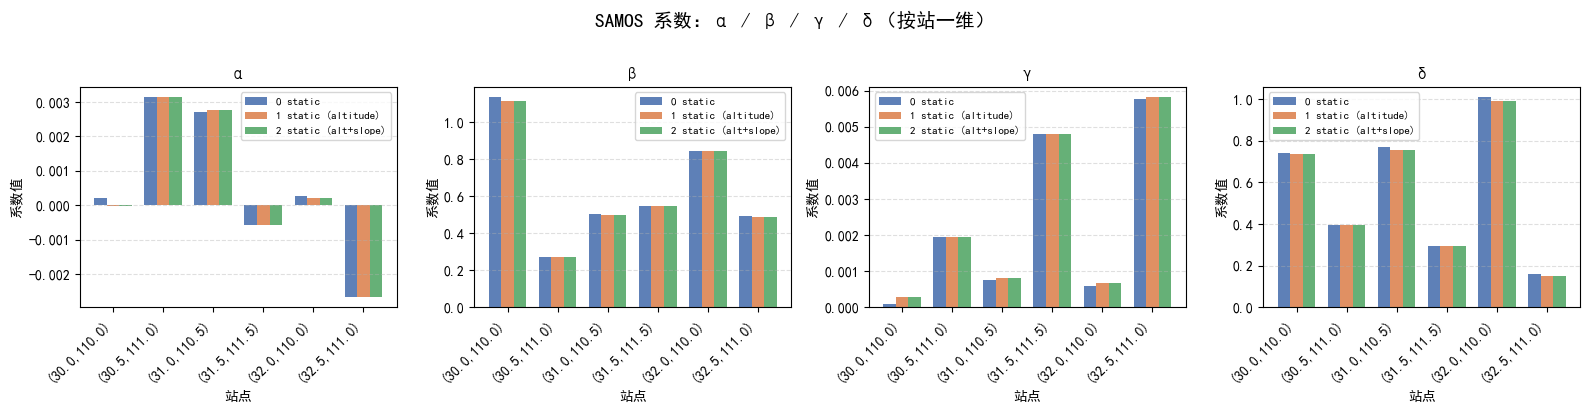

In [3]:
stations = (
    results[0]["apply_fc"][["lat", "lon"]]
    .drop_duplicates()
    .sort_values(["lat", "lon"])
    .reset_index(drop=True)
)
station_labels = [f"({r.lat:.1f},{r.lon:.1f})" for r in stations.itertuples()]
x = np.arange(len(station_labels))
width = 0.25

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
param_names = [
    "emos_coefficient_alpha",
    "emos_coefficient_beta",
    "emos_coefficient_gamma",
    "emos_coefficient_delta",
]
titles = ["α", "β", "γ", "δ"]

for ax, pname, title in zip(axes, param_names, titles):
    for offset, (label, n_static, color) in enumerate(STATIC_CASES):
        vals = coeff_station_values(results[n_static]["coeffs"], pname)
        ax.bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("站点")
    ax.set_ylabel("系数值")
    ax.set_xticks(x)
    ax.set_xticklabels(station_labels, rotation=45, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

fig.suptitle("SAMOS 系数：α / β / γ / δ（按站一维）", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



## 3. 集合订正：各站集合均值

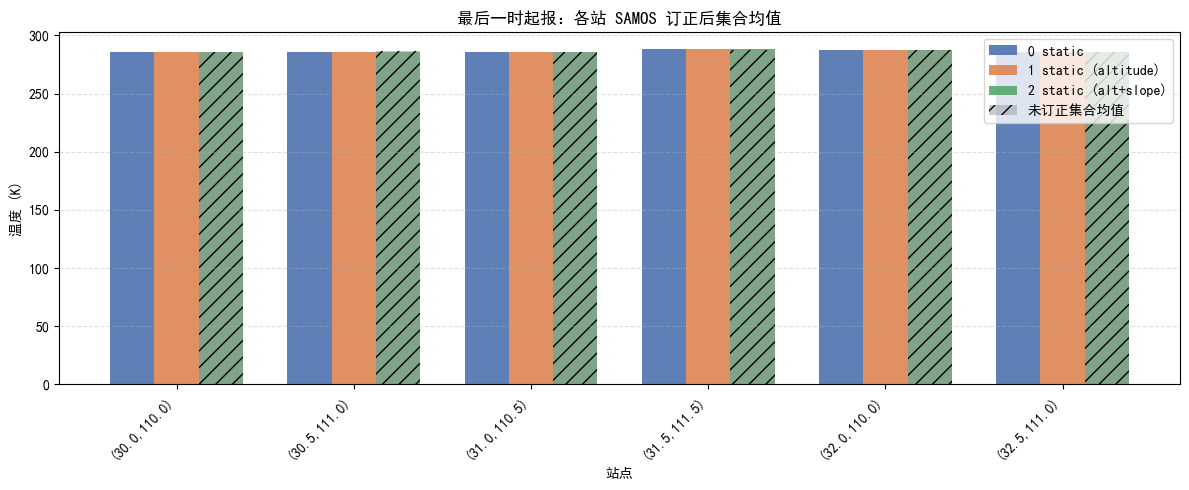

In [4]:
def ensemble_mean_by_station(ens_ds: xr.Dataset) -> np.ndarray:
    da = ens_ds["air_temperature"]
    return station_table(da.mean(GRID_MEMBER_DIM))[da.name].to_numpy()

raw_fc = normalize_grid_input(results[0]["apply_fc"])
raw_mean = station_table(raw_fc.mean(GRID_MEMBER_DIM))[raw_fc.name].to_numpy()

fig, ax = plt.subplots(figsize=(12, 5))
for offset, (label, n_static, color) in enumerate(STATIC_CASES):
    vals = ensemble_mean_by_station(results[n_static]["ensemble"])
    ax.bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
ax.bar(x + width, raw_mean, width=width, label="未订正集合均值", color="#999999", alpha=0.5, hatch="//")
ax.set_title("最后一时起报：各站 SAMOS 订正后集合均值", fontweight="bold")
ax.set_xlabel("站点")
ax.set_ylabel("温度 (K)")
ax.set_xticks(x)
ax.set_xticklabels(station_labels, rotation=45, ha="right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## 4. 阈值概率对比

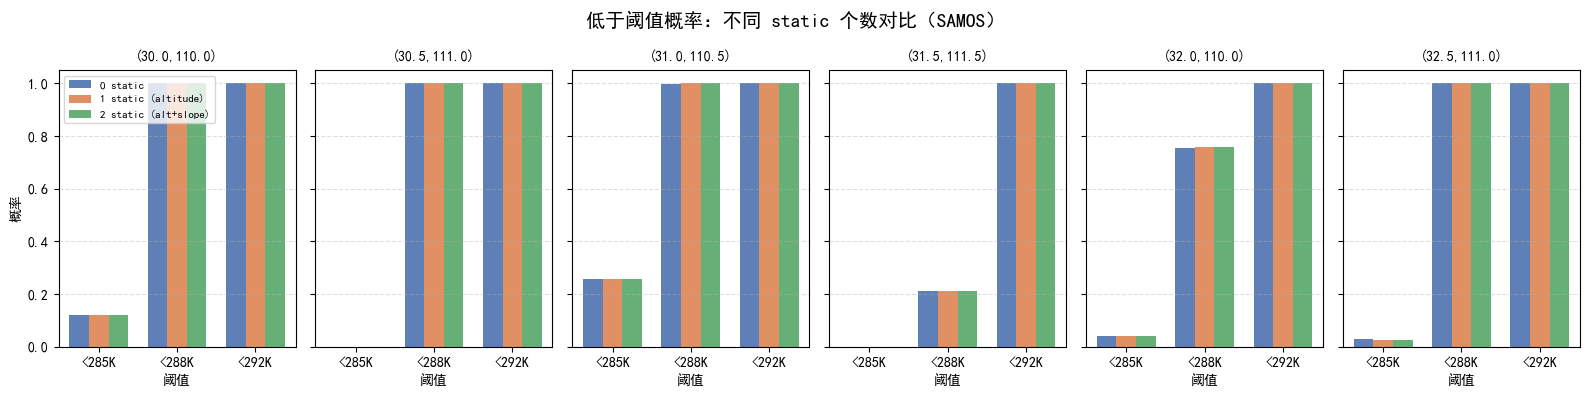

In [5]:
prob_var = "probability_of_air_temperature_below_threshold"
fig, axes = plt.subplots(1, len(station_labels), figsize=(16, 4), sharey=True)
if len(station_labels) == 1:
    axes = [axes]

for s_idx, ax in enumerate(axes):
    for offset, (label, n_static, color) in enumerate(STATIC_CASES):
        prob = results[n_static]["probability"][prob_var]
        st_all = [
            station_table(prob.isel(threshold=t_idx)).iloc[s_idx][prob.name]
            for t_idx in range(len(THRESHOLDS))
        ]
        ax.bar(
            np.arange(len(THRESHOLDS)) + (offset - 1) * width,
            st_all,
            width=width,
            label=label,
            color=color,
            alpha=0.9,
        )
    ax.set_title(station_labels[s_idx], fontsize=10)
    ax.set_xticks(np.arange(len(THRESHOLDS)))
    ax.set_xticklabels([f"<{t:.0f}K" for t in THRESHOLDS])
    ax.set_xlabel("阈值")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    if s_idx == 0:
        ax.set_ylabel("概率")
        ax.legend(fontsize=8)

fig.suptitle("低于阈值概率：不同 static 个数对比（SAMOS）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. 分位值订正对比

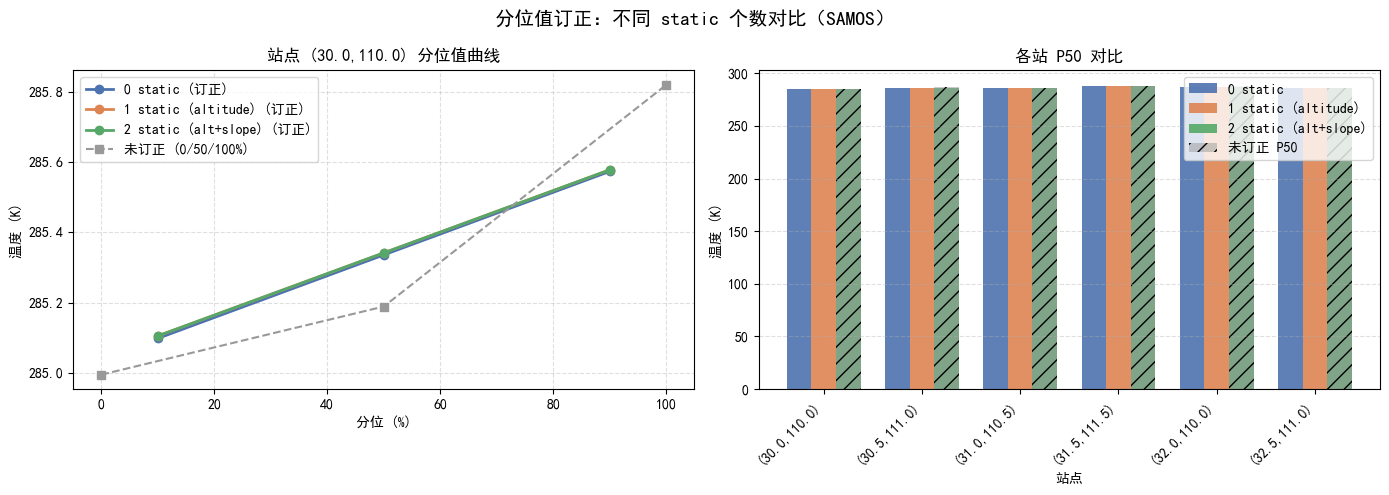

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

site_idx = 0
raw_pct = percentile_forecast(results[0]["apply_fc"])

for label, n_static, color in STATIC_CASES:
    pct = results[n_static]["percentiles"]["air_temperature"]
    vals = [station_value_at(sel_percentile(pct, p), site_idx) for p in OUTPUT_PERCENTILES]
    axes[0].plot(OUTPUT_PERCENTILES, vals, marker="o", label=f"{label} (订正)", color=color, linewidth=2)

raw_vals = [station_value_at(sel_percentile(raw_pct, p), site_idx) for p in RAW_PERCENTILES]
axes[0].plot(
    RAW_PERCENTILES,
    raw_vals,
    marker="s",
    label="未订正 (0/50/100%)",
    color="#999999",
    linestyle="--",
)
axes[0].set_title(f"站点 {station_labels[site_idx]} 分位值曲线", fontweight="bold")
axes[0].set_xlabel("分位 (%)")
axes[0].set_ylabel("温度 (K)")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

for offset, (label, n_static, color) in enumerate(STATIC_CASES):
    pct = results[n_static]["percentiles"]["air_temperature"]
    vals = station_table(sel_percentile(pct, 50.0))[pct.name].to_numpy()
    axes[1].bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
raw_p50 = station_table(sel_percentile(raw_pct, 50.0))[raw_pct.name].to_numpy()
axes[1].bar(x + width, raw_p50, width=width, label="未订正 P50", color="#999999", alpha=0.5, hatch="//")
axes[1].set_title("各站 P50 对比", fontweight="bold")
axes[1].set_xlabel("站点")
axes[1].set_ylabel("温度 (K)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(station_labels, rotation=45, ha="right")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].legend()

fig.suptitle("分位值订正：不同 static 个数对比（SAMOS）", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()